In [5]:
# we are building the model using sigmoid activation function
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from tensorflow.keras.utils import plot_model
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils

In [7]:
# we are loading the mnist data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [8]:
# we are reshaping the images 
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [9]:
# we are doing feature scaling for better accuracy
X_train = X_train / 255
X_test = X_test / 255

In [10]:
# we are converting the data using one hot encoder
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [11]:
# we are building the model
def baseline_model():
	# we are creating our first input layer and hidden layer for CNN
	model = Sequential()
	model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu')) # it is a convolutional operator for filtering windows of two dimensional input
	model.add(MaxPooling2D())  # it checks the maximum values and returns it into the array of smaller size
	model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
	model.add(Flatten()) # it simplifies the array and converts it to one dimensional
	model.add(Dense(128, activation='relu'))
	model.add(Dense(num_classes, activation='sigmoid'))
	# we are compiling the model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

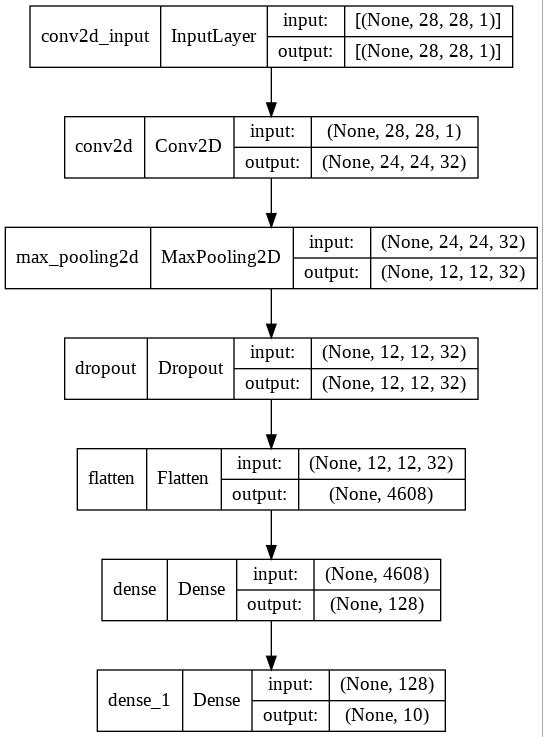

In [12]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=248)

Epoch 1/5
242/242 [==============================] - 40s 162ms/step - loss: 0.2734 - accuracy: 0.9228 - val_loss: 0.0944 - val_accuracy: 0.9735
Epoch 2/5
242/242 [==============================] - 36s 150ms/step - loss: 0.0805 - accuracy: 0.9759 - val_loss: 0.0507 - val_accuracy: 0.9839
Epoch 3/5
242/242 [==============================] - 38s 157ms/step - loss: 0.0566 - accuracy: 0.9832 - val_loss: 0.0442 - val_accuracy: 0.9855
Epoch 4/5
242/242 [==============================] - 34s 141ms/step - loss: 0.0449 - accuracy: 0.9862 - val_loss: 0.0415 - val_accuracy: 0.9860
Epoch 5/5
242/242 [==============================] - 40s 163ms/step - loss: 0.0356 - accuracy: 0.9891 - val_loss: 0.0343 - val_accuracy: 0.9885


we take 5 epochs and batch size = 248 and got accuracy around 0.9891 and loss 0.0356

we got cnn error 1.07%

In [ ]:
# the final representation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 1.07%


In [1]:
# we are building our model using selu 
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from tensorflow.keras.utils import plot_model
from keras.layers import Flatten
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils

In [2]:
# we are loading the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11501568/11490434 [==============================] - 0s 0us/step


In [3]:
# we are reshaping the height width and channels
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [4]:
# we are converting the data inti 0 and 1
X_train = X_train / 255
X_test = X_test / 255

In [5]:
# we are applying one hot encoding here
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [6]:
# we are building the model
def baseline_model():
	# we are creating the first input layera and hidden layer for CNN
	model = Sequential()
	model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'))  # it is a convolutional operator for filtering windows of two dimensional input
	model.add(MaxPooling2D()) # it checks the maximum values and returns it into the array of smaller size
	model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
	model.add(Flatten()) # it simplifies the array and converts it to one dimensional
	model.add(Dense(128, activation='relu'))
	model.add(Dense(num_classes, activation='selu'))
	# we are compiling the model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

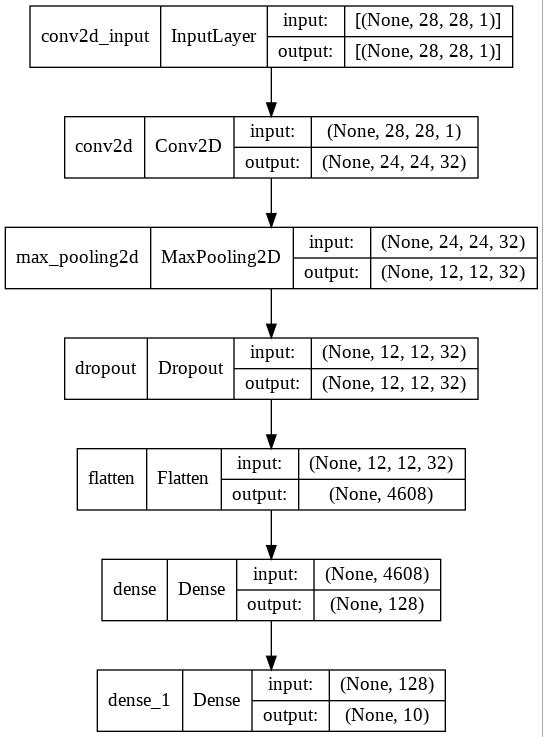

In [7]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=248)

Epoch 1/5
242/242 [==============================] - 37s 150ms/step - loss: 11.1410 - accuracy: 0.1170 - val_loss: 12.7770 - val_accuracy: 0.1010
Epoch 2/5
242/242 [==============================] - 37s 155ms/step - loss: 12.8258 - accuracy: 0.1022 - val_loss: 12.8832 - val_accuracy: 0.1010
Epoch 3/5
242/242 [==============================] - 37s 152ms/step - loss: 12.8948 - accuracy: 0.1022 - val_loss: 12.9284 - val_accuracy: 0.1010
Epoch 4/5
242/242 [==============================] - 42s 173ms/step - loss: 12.9222 - accuracy: 0.1022 - val_loss: 12.9058 - val_accuracy: 0.1010
Epoch 5/5
242/242 [==============================] - 33s 138ms/step - loss: 12.9066 - accuracy: 0.1022 - val_loss: 12.9284 - val_accuracy: 0.1010


we took 5 epochs and ended up getting accuracy around 0.1022 and loss = 12.9066

we got cnn error as 89.90%

In [ ]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 89.90%


In [8]:
# we are building our model using elu
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils

In [9]:
# We are loading the data 
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [10]:
# we are reshaping the height width channels and samples
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [11]:
# we are converting the value in terms of 0 and 1 we are feature scaling here
X_train = X_train / 255
X_test = X_test / 255

In [12]:
# we are applying one hot encoding 
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [13]:
# we are building our model
def baseline_model():
	# we are creating the first input layer and hidden layer of the model
	model = Sequential()
	model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu')) # it is a convolutional operator for filtering windows of two dimensional input
	model.add(MaxPooling2D()) # it checks the maximum values and returns it into the array of smaller size
	model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
	model.add(Flatten())  # it simplifies the array and converts it to one dimensional
	model.add(Dense(128, activation='relu'))
	model.add(Dense(num_classes, activation='elu'))
	# we are compiling the model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

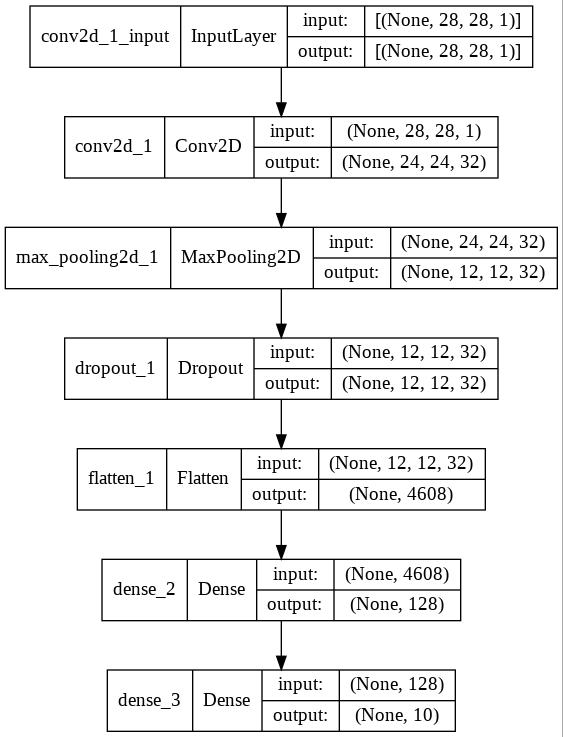

In [14]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=248)

Epoch 1/5
242/242 [==============================] - 38s 155ms/step - loss: 9.5059 - accuracy: 0.2519 - val_loss: 9.7644 - val_accuracy: 0.2894
Epoch 2/5
242/242 [==============================] - 40s 166ms/step - loss: 9.8659 - accuracy: 0.2872 - val_loss: 9.8820 - val_accuracy: 0.2938
Epoch 3/5
242/242 [==============================] - 41s 168ms/step - loss: 9.9065 - accuracy: 0.2841 - val_loss: 9.8998 - val_accuracy: 0.2907
Epoch 4/5
242/242 [==============================] - 34s 139ms/step - loss: 9.9682 - accuracy: 0.2803 - val_loss: 9.9207 - val_accuracy: 0.2868
Epoch 5/5
242/242 [==============================] - 30s 123ms/step - loss: 9.9846 - accuracy: 0.2848 - val_loss: 9.9868 - val_accuracy: 0.2914


we took batch size = 248 and epochs = 5 and got the accuracy of 0.2848 and loss = 9.9846

we got cnn error as 70.86%

In [ ]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 70.86%


In [15]:
# we are building our model using relu 
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils

In [16]:
# we are loading the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [17]:
# we are reshaping the channels sample width and heigth
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [18]:
# we are converting the values into 0 and 1 for better perdictions and accuracy
X_train = X_train / 255
X_test = X_test / 255

In [19]:
# we are applying one hot encode
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [20]:
# we are building the model
def baseline_model():
	# we are creating the first layer of cnn input layer and hidden layer
	model = Sequential()
	model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'))  # it is a convolutional operator for filtering windows of two dimensional input
	model.add(MaxPooling2D()) # it checks the maximum values and returns it into the array of smaller size
	model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
	model.add(Flatten()) # it simplifies the array and converts it to one dimensional
	model.add(Dense(128, activation='relu'))
	model.add(Dense(num_classes, activation='relu'))
	# we are compiling the model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

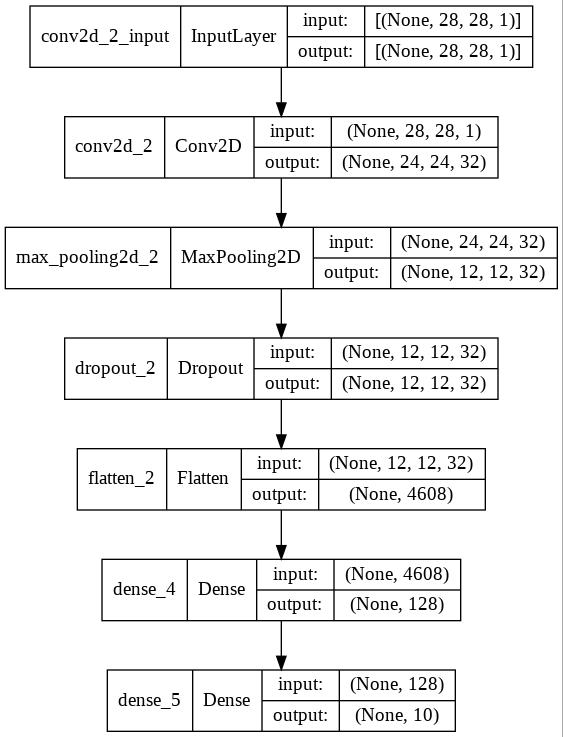

In [21]:

model = baseline_model() 
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=248)

Epoch 1/5
242/242 [==============================] - 35s 144ms/step - loss: nan - accuracy: 0.1503 - val_loss: nan - val_accuracy: 0.0980
Epoch 2/5
242/242 [==============================] - 39s 160ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 3/5
242/242 [==============================] - 38s 155ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 4/5
242/242 [==============================] - 39s 161ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 5/5
242/242 [==============================] - 31s 126ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980


we take epochs 5 and batch size 248 and got the accuracy of 0.0987 and loss = nan

we got cnn error as 90.20%

In [ ]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.20%


In [22]:
# we are building our model using hyperbolic tanh
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Dropout
from keras.layers import Flatten
from tensorflow.keras.utils import plot_model
from keras.layers.convolutional import Conv2D
from keras.layers.convolutional import MaxPooling2D
from keras.utils import np_utils

In [23]:
# we are loading the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [24]:
# we are reshaping the height width channels and samples
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1)).astype('float32')
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1)).astype('float32')

In [25]:
# we are converting the input to 0 and 1 for better accuracy
X_train = X_train / 255
X_test = X_test / 255

In [26]:
# we are applying one hot encode
y_train = np_utils.to_categorical(y_train)
y_test = np_utils.to_categorical(y_test)
num_classes = y_test.shape[1]

In [27]:
# we are building our model and importing the libraries
def baseline_model():
	# we are creating the first input layer and hidden layer of CNN
	model = Sequential()
	model.add(Conv2D(32, (5, 5), input_shape=(28, 28, 1), activation='relu'))  # it is a convolutional operator for filtering windows of two dimensional input
	model.add(MaxPooling2D()) # it checks the maximum values and returns it into the array of smaller size
	model.add(Dropout(0.2)) # we will drop out the weights in order to reduce the overfitting 20% weights will be removed
	model.add(Flatten()) # it simplifies the array and converts it to one dimensional
	model.add(Dense(128, activation='relu'))
	model.add(Dense(num_classes, activation='tanh'))
	# we are compiling the model
	model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
	return model

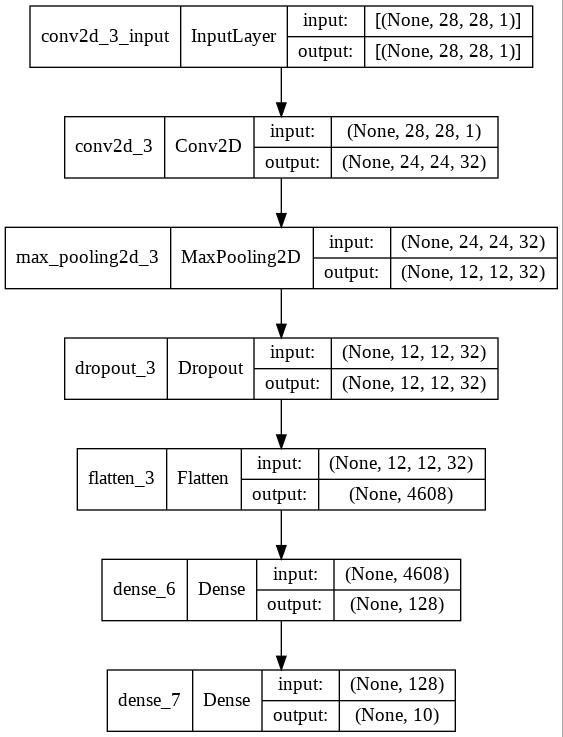

In [28]:

model = baseline_model()
plot_model(model , 'model.jpg' , show_shapes = True) # we are representing our model

In [ ]:
# we are training and evaluating the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=248)

Epoch 1/5
242/242 [==============================] - 36s 145ms/step - loss: 7.9930 - accuracy: 0.2061 - val_loss: 8.9713 - val_accuracy: 0.1279
Epoch 2/5
242/242 [==============================] - 40s 164ms/step - loss: nan - accuracy: 0.1186 - val_loss: nan - val_accuracy: 0.0980
Epoch 3/5
242/242 [==============================] - 39s 162ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 4/5
242/242 [==============================] - 39s 162ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980
Epoch 5/5
242/242 [==============================] - 30s 123ms/step - loss: nan - accuracy: 0.0987 - val_loss: nan - val_accuracy: 0.0980


we take epochs 5 and batch size 248 and get the accuracy around 0.0987 and loss nan

we got cnn error as 90.20%

In [ ]:
# Final evaluation of the model
scores = model.evaluate(X_test, y_test, verbose=0)
print("CNN Error: %.2f%%" % (100-scores[1]*100))

CNN Error: 90.20%
